In [ ]:
# 데이터 분석 및 시각화에 필요한 기본 라이브러리들을 불러옵니다.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn 라이브러리에서 필요한 모듈들을 불러옵니다.
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# TensorFlow Keras 라이브러리를 불러옵니다.
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

1.

In [ ]:
from sklearn.preprocessing import RobustScaler

2.

In [ ]:
emp_df = pd.read_csv('3_employee_salary.csv')

print(emp_df.isnull().sum())

department            23
experience_years      19
education_level       19
position              31
performance_score     22
projects_completed    27
team_size             21
training_hours        24
language_skill        20
salary_krw             0
dtype: int64


3.

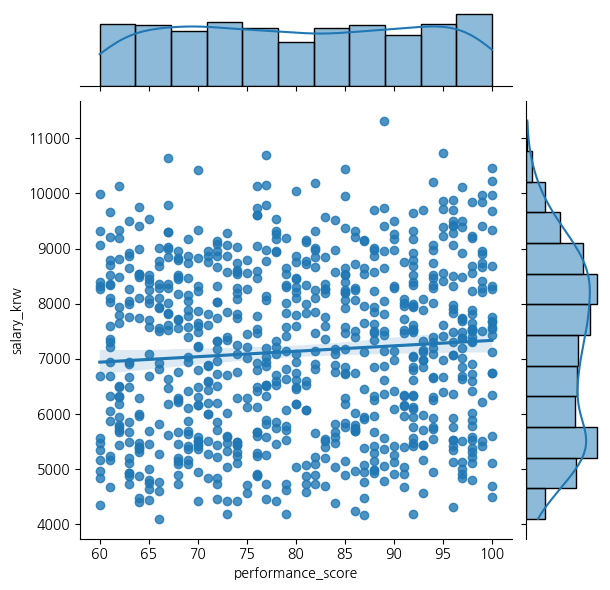

In [ ]:
sns.jointplot(data=emp_df, x='performance_score', y='salary_krw', kind='reg')

In [ ]:
답안03='3'

4

In [ ]:
# 사전 실행 코드
import platform
from matplotlib import rc

if platform.system() == 'Darwin':  # macOS
    rc('font', family='AppleGothic')
else:  # Windows
    rc('font', family='Malgun Gothic')

plt.rcParams['axes.unicode_minus'] = False

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import urllib.request

# 1. 인터넷에서 나눔고딕 폰트 파일을 현재 폴더로 직접 다운로드
font_url = "https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf"
urllib.request.urlretrieve(font_url, "my_nanum_font.ttf")

# 2. 다운로드한 폰트 파일의 경로 지정 및 이름 속성 가져오기
fe = fm.FontEntry(fname="my_nanum_font.ttf", name="MyNanum")
fm.fontManager.ttflist.insert(0, fe)  # Matplotlib 폰트 리스트 맨 앞에 강제 주입

# 3. 주입한 폰트 이름으로 전역 설정 변경 (마이너스 깨짐 방지도 함께)
plt.rc('font', family='MyNanum')
plt.rcParams['axes.unicode_minus'] = False

<Axes: xlabel='position', ylabel='count'>

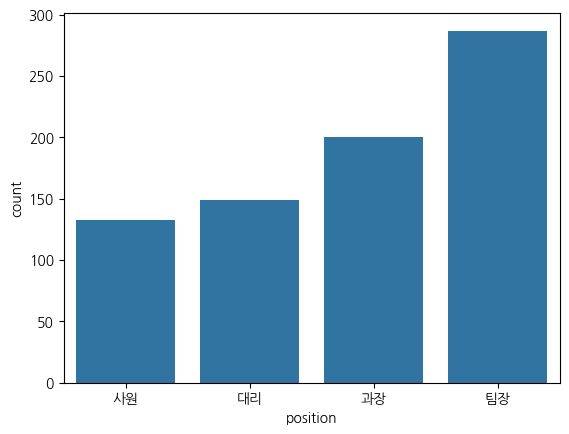

In [ ]:
# 직급 순서를 정의 (리스트)
position_order = ['사원', '대리', '과장', '팀장']

# 시각화
#sns.<blank1>(data=emp_df, x='position', <blank2>=position_order)
sns.countplot(data=emp_df, x='position', order=position_order)

In [ ]:
답안04 = '과장'

5.

In [ ]:
emp_df.groupby(['department', 'position'])['performance_score'].mean()

department  position
개발          과장          79.727273
            대리          78.406250
            사원          80.228571
            팀장          80.176471
마케팅         과장          83.653846
            대리          82.750000
            사원          81.516129
            팀장          79.750000
영업          과장          80.452381
            대리          78.562500
            사원          79.689655
            팀장          78.314286
인사          과장          82.711111
            대리          79.106383
            사원          77.419355
            팀장          79.621212
Name: performance_score, dtype: float64

In [ ]:
답안05 = '78.31'

6.

In [ ]:
emp_pre = emp_df.copy()

emp_pre['performance_score'] = emp_pre['performance_score'].fillna(emp_pre['performance_score'].mean(), inplace=True)
emp_pre['projects_completed'] = emp_pre['projects_completed'].fillna(emp_pre['projects_completed'].mean(), inplace=True)
emp_pre['team_size'] = emp_pre['team_size'].fillna(emp_pre['team_size'].mean(), inplace=True)

emp_pre.dropna(subset=['department', 'education_level', 'position'], inplace=True)

/tmp/ipykernel_2033/2184926212.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  emp_pre['performance_score'] = emp_pre['performance_score'].fillna(emp_pre['performance_score'].mean(), inplace=True)
/tmp/ipykernel_2033/2184926212.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

7.

In [ ]:
emp_pre['education_level'] = emp_pre['education_level'].map({'고졸':0.0, '학사':1.0, '석사':2.0, '박사':3.0})
emp_pre['position'] = emp_pre['position'].map({'사원':0, '대리':1.0, '과장':2.0, '팀장':3.0})
emp_pre['language_skill'] = emp_pre['language_skill'].map({'하':0.0, '중':1.0, '상':2.0})

8.

In [ ]:
emp_encoded = pd.get_dummies(data=emp_pre, columns=['department'], dtype=int)

from sklearn.model_selection import train_test_split

X = emp_encoded.drop(columns=['salary_krw'])
y = emp_encoded['salary_krw']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=123)

9.

In [ ]:
from sklearn.preprocessing import RobustScaler

rs = RobustScaler()

X_train_scaled = rs.fit_transform(X_train)
X_valid_scaled = rs.transform(X_valid)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_data.py:1642: RuntimeWarning: All-NaN slice encountered
  self.center_ = np.nanmedian(X, axis=0)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:1424: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


10.

In [ ]:
from sklearn.svm import SVR

model_svr = SVR(kernel='rbf', C=1.0)

model_svr.fit(X_train_scaled, y_train)

ValueError: Input X contains NaN.
SVR does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

11.

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

model_gbr = GradientBoostingRegressor(n_estimators=150, learning_rate=0.1, max_depth=3, random_state=123)

model_gbr.fit(X_train_scaled, y_train)

print(pd.DataFrame([model_gbr.feature_importances_], columns= X.columns))

ValueError: Input X contains NaN.
GradientBoostingRegressor does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

12.

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred_svr = model_svr.predict(X_valid_scaled)
y_pred_gbr = model_gbr.predict(X_valid_scaled)

print('svr')
print('mse', np.sqrt(mean_squared_error(y_valid, y_pred_svr)))
print('r2', r2_score(y_valid, y_pred_svr))

print('gbr')
print('mse', np.sqrt(mean_squared_error(y_valid, y_pred_gbr)))
print('r2', r2_score(y_valid, y_pred_gbr))

NotFittedError: This SVR instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

13.

In [ ]:
model=Sequential()

model.add(Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

model.fit(X_train_scaled, y_train, epochs=50, batch_size=8, validation_data=(X_valid_scaled, y_valid))

14.

In [ ]:
# 아래 코드를 실행하여 시뮬레이션용 데이터를 생성하세요.
new_employee_data = np.array([[10, 2, 2, 85.0, 20.0, 10.0, 50.0, 2, 1, 0, 0, 0]])

In [ ]:
new_employee_data_scaled = rs.transform(new_employee_data)

predicted_salary_dl = model.pre